In [1]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns


In [2]:
# Simulate a simple degradation dataset
np.random.seed(42)
n = 500  # number of samples

data = pd.DataFrame({
    'Cycle': np.random.randint(0, 2000, n),
    'Temperature': np.random.choice([15, 25, 35, 45], n),
    'DOD': np.random.choice([60, 80, 100], n),
    'Avg_SOC': np.random.uniform(20, 80, n),
    'C_rate': np.random.choice([0.5, 1, 1.5, 2], n),
    'Dynamic': np.random.choice([0, 1], n),  # 0=constant, 1=dynamic
})

# Synthetic degradation law (for illustration)
data['Capacity_Ah'] = (
    116
    - 0.002 * data['Cycle']
    - 0.03 * (data['Temperature'] - 25).clip(lower=0)
    - 0.015 * (data['C_rate'] - 1.0)**2
    - 0.1 * (data['Dynamic'])
    + np.random.normal(0, 0.05, n)
)

data.head()



,Cycle,Temperature,DOD,Avg_SOC,C_rate,Dynamic,Capacity_Ah
0,1126,25,100,26.856038,1.5,1,113.633683
1,1459,25,60,44.870275,1.0,1,112.976130
2,860,35,80,71.811088,1.5,0,113.974892
3,1294,45,80,75.377614,1.5,0,112.836965
4,1130,25,100,47.942007,1.0,0,113.724573


In [3]:
features = ['Cycle', 'Temperature', 'DOD', 'Avg_SOC', 'C_rate', 'Dynamic']
target = 'Capacity_Ah'

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.3f} Ah")
print(f"R² Score: {r2:.3f}")


Mean Absolute Error: 0.063 Ah
R² Score: 0.996


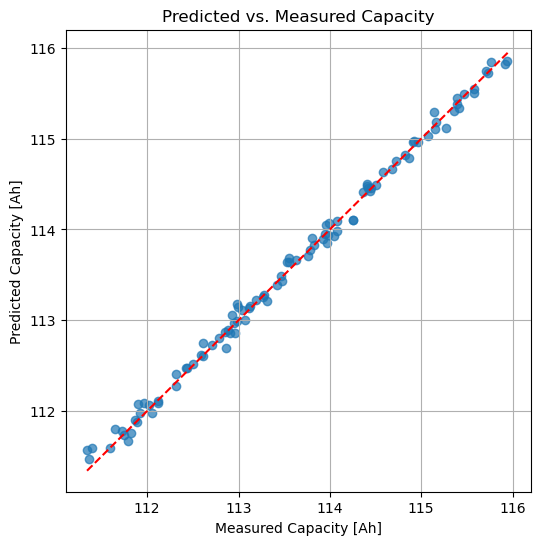

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Measured Capacity [Ah]")
plt.ylabel("Predicted Capacity [Ah]")
plt.title("Predicted vs. Measured Capacity")
plt.grid(True)
plt.show()


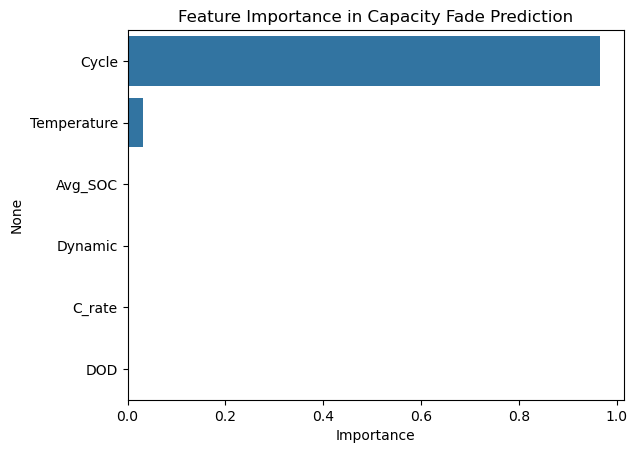

In [6]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance in Capacity Fade Prediction")
plt.xlabel("Importance")
plt.show()


In [7]:
sample = pd.DataFrame({
    'Cycle': [500],
    'Temperature': [45],
    'DOD': [100],
    'Avg_SOC': [60],
    'C_rate': [1.5],
    'Dynamic': [1]
})

pred_capacity = rf.predict(sample)[0]
print(f"Predicted capacity after 500 cycles: {pred_capacity:.2f} Ah")


Predicted capacity after 500 cycles: 114.34 Ah


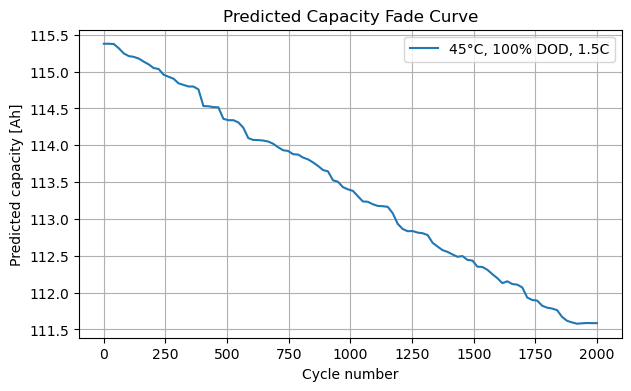

In [8]:
cycles = np.linspace(0, 2000, 100)
temp = 45
dod = 100
soc = 60
crate = 1.5
dynamic = 1

inputs = pd.DataFrame({
    'Cycle': cycles,
    'Temperature': [temp]*len(cycles),
    'DOD': [dod]*len(cycles),
    'Avg_SOC': [soc]*len(cycles),
    'C_rate': [crate]*len(cycles),
    'Dynamic': [dynamic]*len(cycles)
})

pred_curve = rf.predict(inputs)

plt.figure(figsize=(7,4))
plt.plot(cycles, pred_curve, label=f'{temp}°C, {dod}% DOD, {crate}C')
plt.xlabel('Cycle number')
plt.ylabel('Predicted capacity [Ah]')
plt.title('Predicted Capacity Fade Curve')
plt.legend()
plt.grid(True)
plt.show()
